## Tiffany Williams - EDA ##
### Exploring the Effects of Pollutants on Asthma ER Visits across NYC 🗽 ###

In [61]:
import matplotlib.pyplot as plt
import requests
import pandas as pd

In [22]:
url = "https://data.cityofnewyork.us/resource/c3uy-2p5r.json"
response = requests.get(url)

In [23]:
df = pd.DataFrame(response.json())

In [ ]:
# determine the size of the dataset
df.shape

(1000, 11)

In [ ]:
# determine the shape of the dataset
df.head()

,unique_id,indicator_id,name,measure,measure_info,geo_type_name,geo_join_id,geo_place_name,time_period,start_date,data_value
0,876921,375,Nitrogen dioxide (NO2),Mean,ppb,UHF42,303,East Harlem,Summer 2023,2023-06-01T00:00:00.000,13.827549
1,877173,375,Nitrogen dioxide (NO2),Mean,ppb,CD,304,Bushwick (CD4),Summer 2023,2023-06-01T00:00:00.000,12.875651
2,878162,386,Ozone (O3),Mean,ppb,CD,109,Morningside Heights and Hamilton Heights (CD9),Summer 2023,2023-06-01T00:00:00.000,30.990763
3,876987,375,Nitrogen dioxide (NO2),Mean,ppb,UHF34,101,Kingsbridge - Riverdale,Summer 2023,2023-06-01T00:00:00.000,13.053878
4,878225,386,Ozone (O3),Mean,ppb,UHF42,305,Upper East Side,Summer 2023,2023-06-01T00:00:00.000,31.244535


###  📡 Step 1: Data Collection ###
*Let's use the NYC Open Data API to explore what pollutants are contributing to asthma across NYC neighbourhoods*

In [26]:
df.columns.tolist()

['unique_id',
 'indicator_id',
 'name',
 'measure',
 'measure_info',
 'geo_type_name',
 'geo_join_id',
 'geo_place_name',
 'time_period',
 'start_date',
 'data_value']

In [27]:
df.describe()

,unique_id,indicator_id,name,measure,measure_info,geo_type_name,geo_join_id,geo_place_name,time_period,start_date,data_value
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,3,3,1,2,5,72,114,4,4,874
top,876921,375,Nitrogen dioxide (NO2),Mean,ppb,CD,202,East Harlem,Summer 2023,2023-06-01T00:00:00.000,13.82754858
freq,1,426,426,1000,575,418,23,15,423,423,2


### 🔢 Step 2: Univariate Analysis ###
 *Let's explore variables individually for its distributions*

In [234]:
df['geo_type_name'].value_counts()

geo_type_name
CD          418
UHF42       299
UHF34       240
Borough      36
Citywide      7
Name: count, dtype: int64

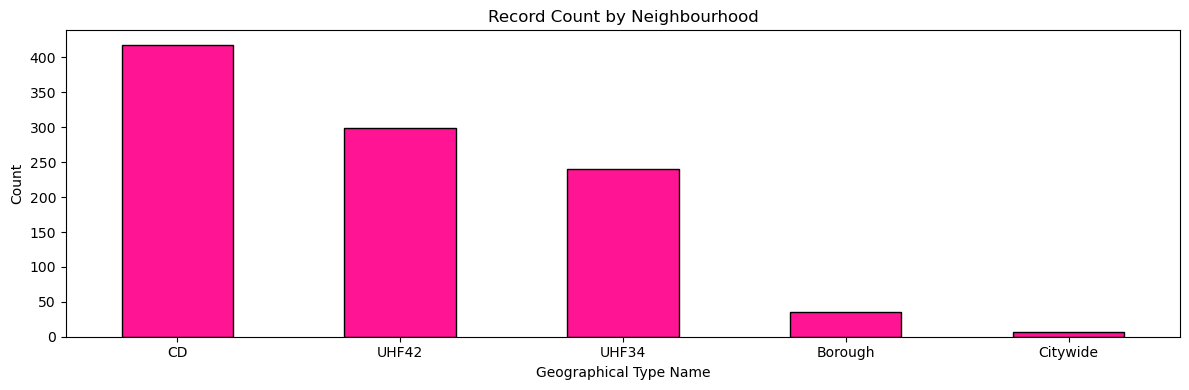

In [230]:
df['geo_type_name'].value_counts().plot(kind='bar', figsize=(12,4), color='deeppink', edgecolor='black')
plt.title('Record Count by Neighbourhood')
plt.xticks(rotation=0)
plt.xlabel('Geographical Type Name')
plt.ylabel('Count')


plt.tight_layout()
plt.show()

In [ ]:
# what values are we looking at (only the discrete ones)
df['time_period'].unique()

<StringArray>
['Summer 2023', 'Annual Average 2023', 'Winter 2022-23', 'Summer 2022']
Length: 4, dtype: str

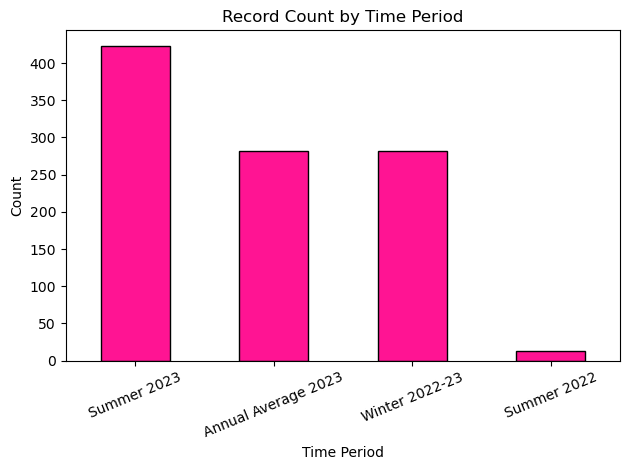

In [235]:
df['time_period'].value_counts().plot(kind='bar', color='deeppink', edgecolor='black')
plt.title('Record Count by Time Period')
plt.xticks(rotation=22.5)
plt.xlabel('Time Period')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


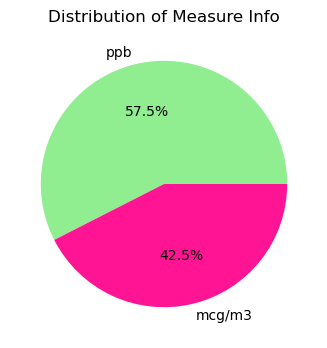

In [237]:
df['measure_info'].value_counts().plot(kind='pie', figsize=(12,4), colors=['lightgreen', 'deeppink'], autopct='%1.1f%%')

plt.title('Distribution of Measure Info')

plt.show()


###  📊 Step 3: Bivariate Data Analysis ###
*Let's compare any potential relationships between pollutant measurements and time periods across NYC neighbourhoods.*

In [154]:
df['data_value'].dtype

dtype('float64')

In [215]:
#convert the String type data_value to numbers, NaNs in place of non-numbers
df['data_value'] = pd.to_numeric(df['data_value'], errors='coerce')

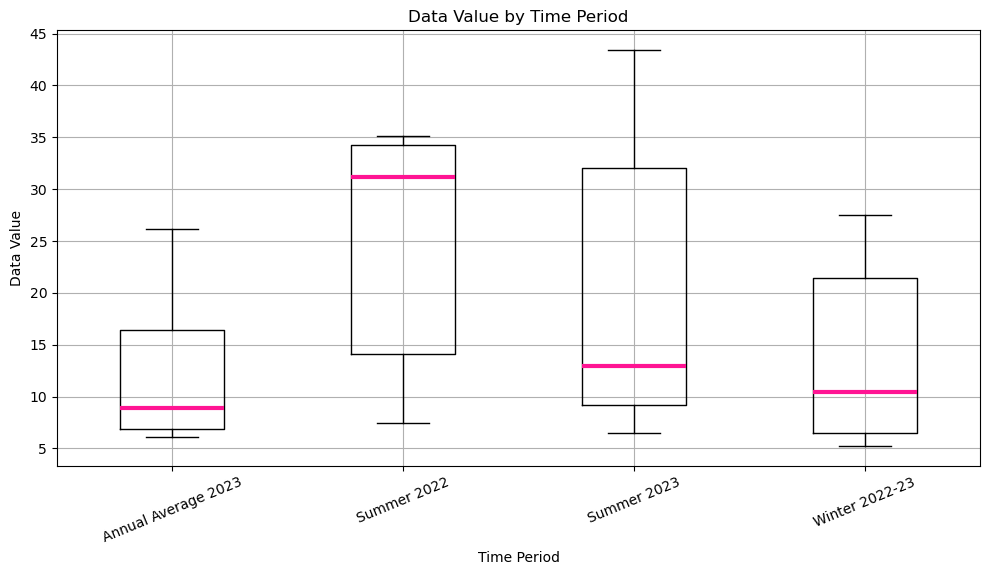

In [217]:
df.boxplot(column='data_value', by='time_period', color='black', figsize=(10,6),
           medianprops= dict(color='deeppink', linewidth=3))
plt.title('Data Value by Time Period')
plt.suptitle('')
plt.xlabel('Time Period')
plt.ylabel('Data Value')
plt.xticks(rotation=22.5)

plt.tight_layout()
plt.show()

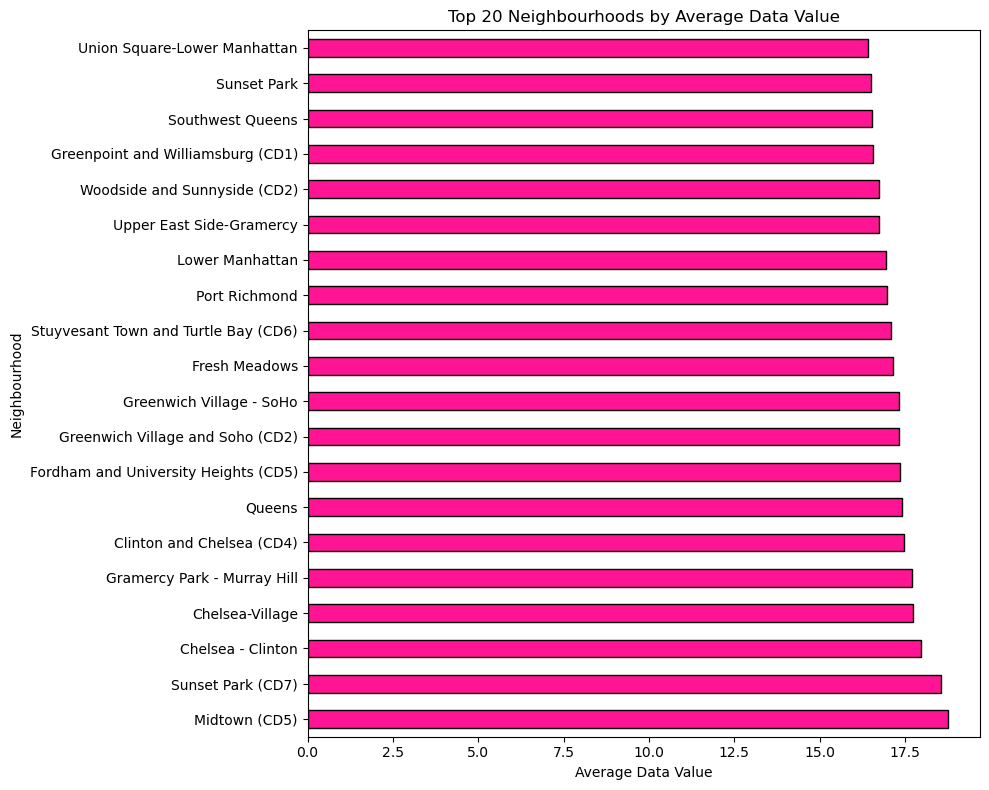

In [218]:
df.groupby('geo_place_name')['data_value'].mean().sort_values(ascending=False).head(20).plot(kind='barh', color='deeppink', edgecolor='black', figsize=(10,8))

plt.title('Top 20 Neighbourhoods by Average Data Value')
plt.xlabel('Average Data Value')
plt.ylabel('Neighbourhood')
plt.tight_layout()
plt.show()

### 🔍 Step 4: Observations ###
*Let's interpret the findings and assess whether the data supports our hypothesis that environmental pollutants contribute to asthma rates in NYC*  

* **DATA x TIME PERIOD - BOX PLOT:** *Summer 2022* has the highest median data values of all the time periods. Conversely, *Annual Average 2023* has the lowest median data values. There seems to be a larger variability in the pollution and asthma instances during the summer season. I wonder what else could be causing this, beyond the data, (e.g., increased time spent outdoors).

* **TOP 20 - BAR CHART:** *Midtown (CD5)* and *Sunset Park (CD7)* recorded the highest average data values, suggesting there are higher pollutant levels in those two areas. The values across the top twenty neighbourhoods are consistently between 16-19, showing this is a norm for many NYC neighbourhoods.